<a href="https://colab.research.google.com/github/Jayaseelan06744/Assignment2_Snowflake_Schema_Visualization/blob/main/Snowflake_Schema_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


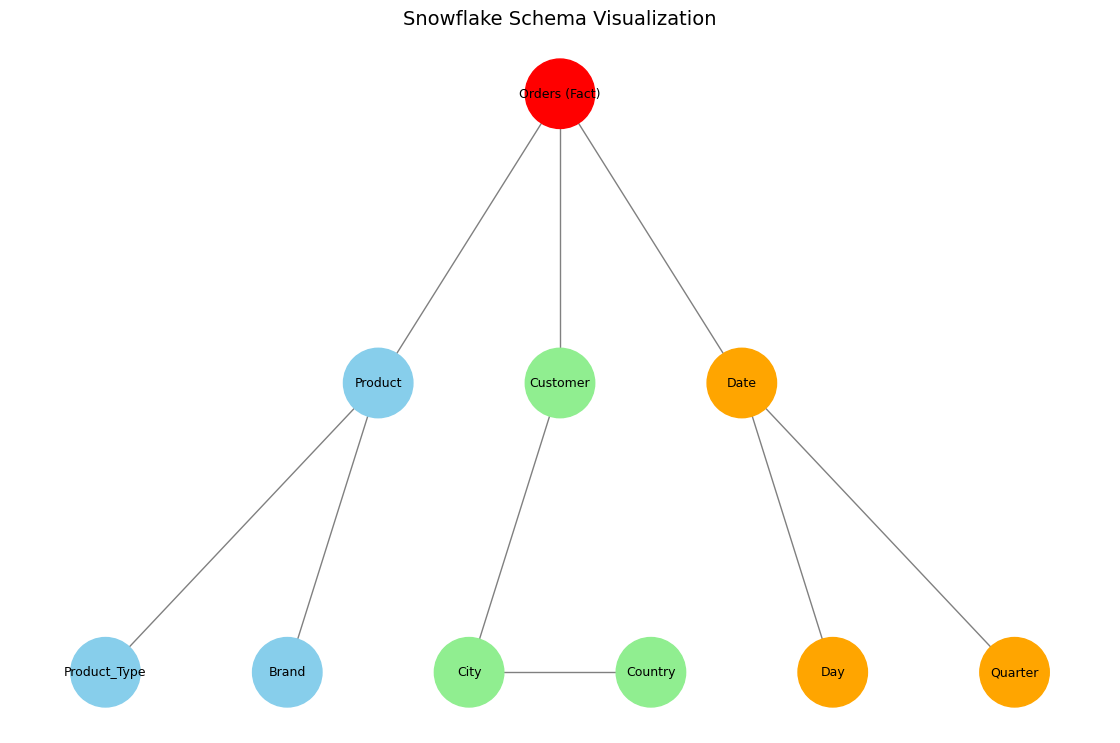

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create graph
G = nx.Graph()

# -------- ADD NODES --------
# Fact Table
G.add_node("Orders (Fact)", layer=0, color="red")

# Dimension Tables (removed "Dim")
G.add_node("Product", layer=1, color="skyblue")
G.add_node("Customer", layer=1, color="lightgreen")
G.add_node("Date", layer=1, color="orange")

# Sub-dimensions
G.add_node("Product_Type", layer=2, color="skyblue")
G.add_node("Brand", layer=2, color="skyblue")

G.add_node("City", layer=2, color="lightgreen")
G.add_node("Country", layer=2, color="lightgreen")

G.add_node("Day", layer=2, color="orange")
G.add_node("Quarter", layer=2, color="orange")

# -------- ADD EDGES --------
G.add_edges_from([
    ("Orders (Fact)", "Product"),
    ("Orders (Fact)", "Customer"),
    ("Orders (Fact)", "Date"),

    ("Product", "Product_Type"),
    ("Product", "Brand"),

    ("Customer", "City"),
    ("City", "Country"),

    ("Date", "Day"),
    ("Date", "Quarter")
])

# -------- CUSTOM LAYOUT --------
pos = {}

layer_positions = {
    0: 0,
    1: 2,
    2: 4
}

layers = {}
for node, data in G.nodes(data=True):
    layer = data['layer']
    layers.setdefault(layer, []).append(node)

for layer, nodes in layers.items():
    y = layer_positions[layer]
    x_spacing = 2
    start_x = - (len(nodes) - 1)

    for i, node in enumerate(nodes):
        pos[node] = (start_x + i * x_spacing, -y)

# -------- COLORS --------
colors = [G.nodes[node]['color'] for node in G.nodes()]

# -------- DRAW --------
plt.figure(figsize=(11, 7))

nx.draw(
    G, pos,
    with_labels=True,
    node_color=colors,
    node_size=2500,
    font_size=9,
    edge_color="gray"
)

plt.title("Snowflake Schema Visualization", fontsize=14)
plt.axis("off")
plt.show()